In [1]:
import ssl
import certifi

import numpy as np
import matplotlib.pyplot as plt 
import torch
from torchvision import datasets, transforms

In [2]:
mnist = datasets.MNIST(
    root = "./data",
    train = True,
    download=True,
    transform=transforms.ToTensor()
)

print(len(mnist))
img, label = mnist[0]
print(img.shape)
print(label)

60000
torch.Size([1, 28, 28])
5


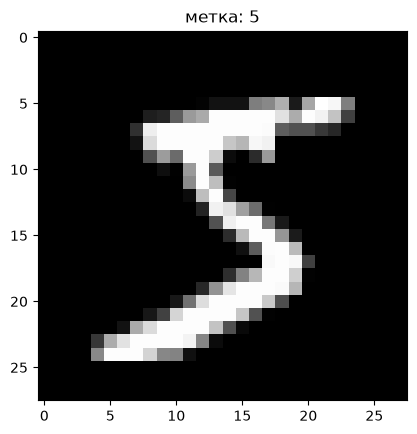

In [3]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"метка: {label}")
plt.show()

In [4]:
mask = (mnist.targets == 0) | (mnist.targets == 1)

X = mnist.data[mask]
y = mnist.targets[mask]
print(X.shape)

torch.Size([12665, 28, 28])


In [5]:
print((y == 0).sum())
print((y == 1).sum())

tensor(5923)
tensor(6742)


In [6]:
X = X.reshape(-1, 784)
y = y.reshape(-1, 1).float()

X = X.float() / 255.0
print(X.min(), X.max())   # ждём 0.0 и 1.0
print(X.dtype)  
print(y.shape, y.dtype)          # ждём torch.float32

tensor(0.) tensor(1.)
torch.float32
torch.Size([12665, 1]) torch.float32


In [7]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(784, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

print(model)
print(sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Linear(in_features=784, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)
12577


In [8]:
mnist_test = datasets.MNIST(
    root = "./data",
    train = False,
    download=True,
    transform=transforms.ToTensor()
)
print(len(mnist_test))

mask = (mnist_test.targets == 0) | (mnist_test.targets == 1)
X_test = mnist_test.data[mask]
y_test = mnist_test.targets[mask]
print(X_test.shape)

y_test = y_test.reshape(-1, 1).float()
print(y_test.shape, y_test.dtype)

X_test = X_test.reshape(-1, 784)
X_test = X_test.float() / 255.0
print(X_test.min(), X_test.max())

print(X_test.shape, X_test.dtype)



10000
torch.Size([2115, 28, 28])
torch.Size([2115, 1]) torch.float32
tensor(0.) tensor(1.)
torch.Size([2115, 784]) torch.float32


In [9]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
losses = []

for epoch in range(1000):
    pred = model(X)
    loss = loss_fn(pred, y)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.4f}")




epoch 0: loss = 0.6798
epoch 100: loss = 0.0164
epoch 200: loss = 0.0062
epoch 300: loss = 0.0037
epoch 400: loss = 0.0027
epoch 500: loss = 0.0021
epoch 600: loss = 0.0017
epoch 700: loss = 0.0014
epoch 800: loss = 0.0011
epoch 900: loss = 0.0009


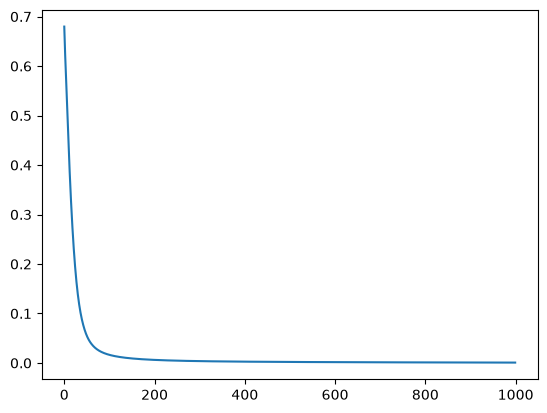

In [10]:
plt.plot(losses)

In [11]:
with torch.no_grad():
    test_pred = model(X_test)

predicted_class = (test_pred > 0.5).float()
accuracy = (predicted_class == y_test).float().mean()
print(accuracy)

tensor(0.9995)


In [13]:
wrong = (predicted_class != y_test).flatten()
wrong_indices = torch.where(wrong)
print(wrong_indices)
print(f"Ошибок: {len(wrong_indices)}")

(tensor([2031]),)
Ошибок: 1


In [15]:
idx  = wrong_indices[0]

img = X_test[idx].reshape(28, 28)
true_label = int(y_test[idx].item())
pred_prob = test_pred[idx].item()

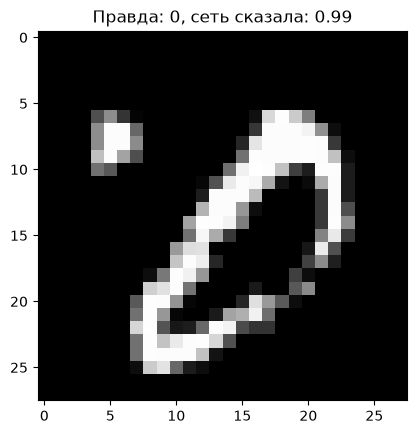

In [16]:
plt.imshow(img, cmap="gray")
plt.title(f"Правда: {true_label}, сеть сказала: {pred_prob:.2f}")
plt.show()

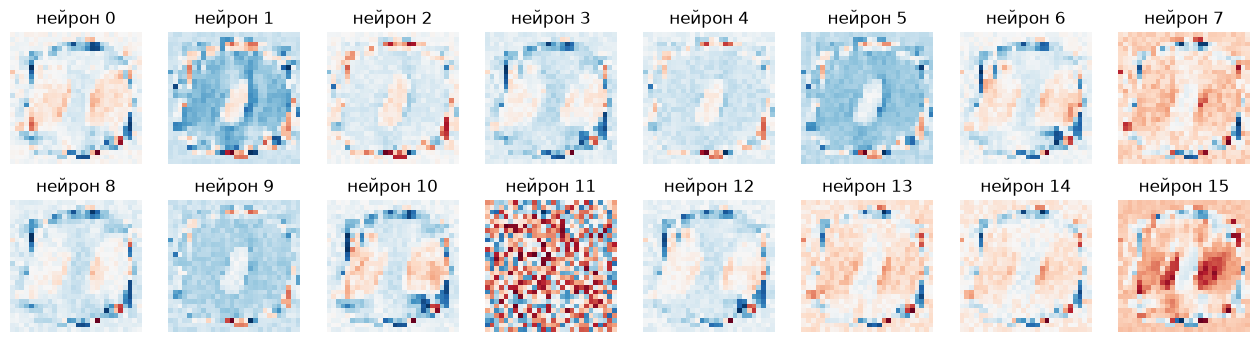

In [20]:
weights = model[0].weight.detach()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i, ax in enumerate(axes.flat):
    trafaret = weights[i].reshape(28, 28)
    ax.imshow(trafaret, cmap="RdBu")
    ax.set_title(f'нейрон {i}')
    ax.axis("off")

plt.show()
